In [46]:
import em_utils.mt_simple as mt
import matplotlib.pyplot as plt
import numpy as np
import datetime
from scipy.constants import mu_0

import importlib

## IRIS
[transfer functions](https://ds.iris.edu/spud/emtf)

In [47]:
mt = importlib.reload(mt)

## Tiny Town!

In [3]:
cop24 = np.load('data/Lab5/cop24.npz')

ex_raw = cop24['ex_raw']
ey_raw = cop24['ey_raw']
hx_raw = cop24['hx_raw']
hy_raw = cop24['hy_raw']

cop24_az = {
    'ex': 334.3 * np.pi/180, #degrees
    'ey': 64.3 * np.pi/180,
    'hx': 8.3 * np.pi/180,
    'hy' : 98.3 * np.pi/180,
}

dipole_length = 100
e_gain = 409600000.0

start = datetime.datetime.fromisoformat("2018-09-13T15:14:30+00:00")
sample_rate = 1 #Hz

time_delay = {
    "ex":datetime.timedelta(seconds=-0.285),
    "ey":datetime.timedelta(seconds=-0.285),
    "hx":datetime.timedelta(seconds=-0.192),
    "hy":datetime.timedelta(seconds=-0.201),
    "hz":datetime.timedelta(seconds=-0.21),
}

nims_low_pass_e = {
    'p':[-3.883009+11.951875j,-3.883009-11.951875j,-10.166194 +7.386513j,-10.166194 -7.386513j,-12.566371 +0.j],
    'z': [],
    'k':313383.493219835
}

nims_high_pass_e = {
    'p':[-0.000167, ],
    'z':[0.0],
    'k':1.00000000378188,
}


h_gain = 100
nims_low_pass_h = {
    'p':[-6.283185+10.882477j, -6.283185-10.882477j,-12.566371+0.j],
    'z':[],
    'k':2002.26936395594 * 1E9 * mu_0 # 1E-9 / mu_0 # V/nT -> , # last bit is nT -> A/m
}

In [4]:
ex = mt.ElectricChannel(
    ex_raw, azimuth=334.3 * np.pi/180, gain=[dipole_length, e_gain], zpk_filter=[nims_low_pass_e, nims_high_pass_e], sample_rate=1, start_time=start, time_delay=-0.285
)
ey = mt.ElectricChannel(
    ey_raw, azimuth=64.3 * np.pi/180, gain=[dipole_length, e_gain], zpk_filter=[nims_low_pass_e, nims_high_pass_e], sample_rate=1, start_time=start, time_delay=-0.285
)
hx = mt.MagneticChannel(
    hx_raw, azimuth=8.3 * np.pi/180, gain=[h_gain], zpk_filter=[nims_low_pass_h], sample_rate=1, start_time=start, time_delay=-0.285
)
hy = mt.MagneticChannel(
    hy_raw, azimuth=98.3 * np.pi/180, gain=[h_gain], zpk_filter=[nims_low_pass_h], sample_rate=1, start_time=start, time_delay=-0.285
)
cop = mt.MTTimeChannelCollection(ex, ey, hx, hy)

## Carter Lake

In [5]:
coo24 = np.load('data/lab5/coo24.npz')

coo24_az = {
    'ex': 337.4 * np.pi/180, #degrees
    'ey': 67.4 * np.pi/180,
    'hx': 8.4 * np.pi/180,
    'hy' : 98.4 * np.pi/180,
}

ex_raw = coo24['ex_raw']
ey_raw = coo24['ey_raw']
hx_raw = coo24['hx_raw']
hy_raw = coo24['hy_raw']

coo24_start = datetime.datetime.fromisoformat("2018-09-12T15:39:54+00:00")

ex = mt.ElectricChannel(
    ex_raw, azimuth=337.4 * np.pi/180, gain=[dipole_length, e_gain], zpk_filter=[nims_low_pass_e, nims_high_pass_e], sample_rate=1, start_time=coo24_start, time_delay=-0.285
)
ey = mt.ElectricChannel(
    ey_raw, azimuth=67.4 * np.pi/180, gain=[dipole_length, e_gain], zpk_filter=[nims_low_pass_e, nims_high_pass_e], sample_rate=1, start_time=coo24_start, time_delay=-0.285
)
hx = mt.MagneticChannel(
    hx_raw, azimuth=8.4 * np.pi/180, gain=[h_gain], zpk_filter=[nims_low_pass_h], sample_rate=1, start_time=coo24_start, time_delay=-0.285
)
hy = mt.MagneticChannel(
    hy_raw, azimuth=98.4 * np.pi/180, gain=[h_gain], zpk_filter=[nims_low_pass_h], sample_rate=1, start_time=coo24_start, time_delay=-0.285
)

coo = mt.MTTimeChannelCollection(ex, ey, hx, hy)

## Plotting channels

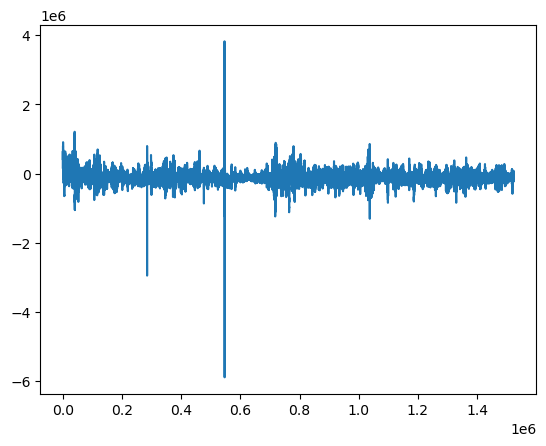

In [6]:
cop.channels[0].plot()

In [7]:
COP = cop.frequency_spectrum().calibrate()

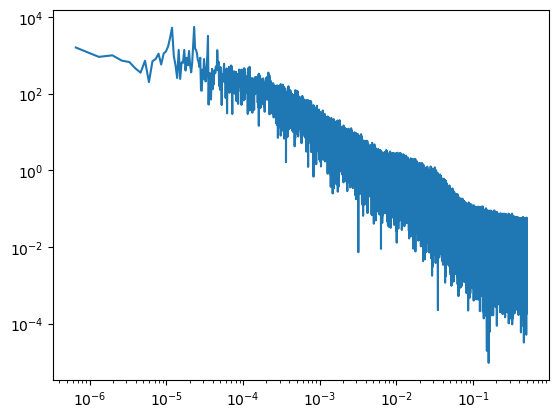

In [8]:
ch = COP.channels[3]
ch.plot()

In [9]:
f, Z = mt.calculate_Z(COP)
rho_a = mt.calc_rho_a(f, Z)

Text(0, 0.5, '$\\rho_a$ $(\\Omega m)$')

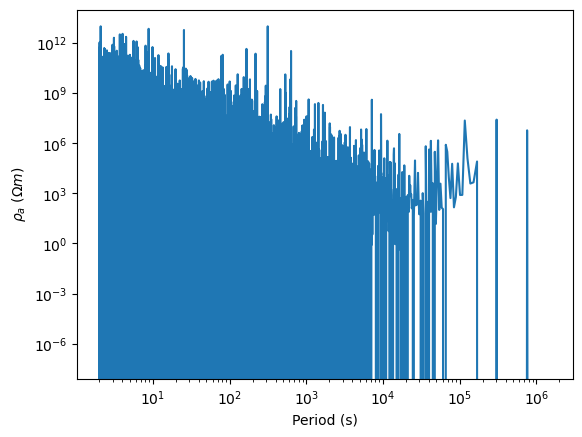

In [10]:
plt.loglog(1/f, rho_a[..., 0, 1])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")

## splitting data

In [11]:
cop_split = cop.split(10)
COP_split = cop_split.frequency_spectrum().calibrate()

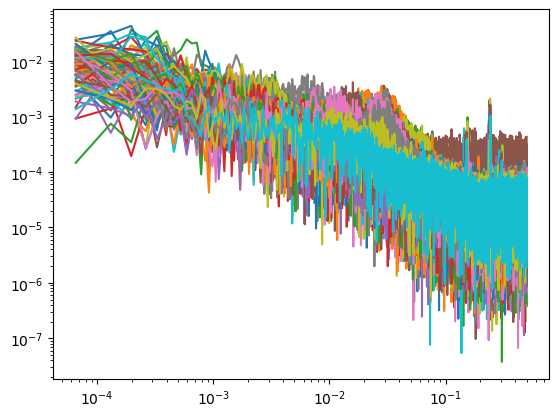

In [12]:
COP_split.channels[0].plot()

In [13]:
f, Z = mt.calculate_Z(COP_split)
rho_a = mt.calc_rho_a(f, Z)

Text(0, 0.5, '$\\rho_a$ $(\\Omega m)$')

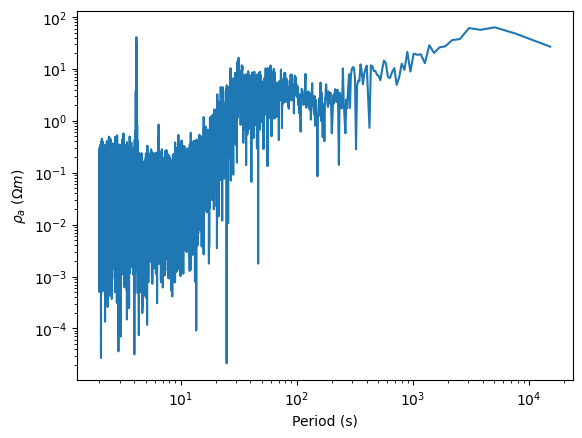

In [14]:
plt.loglog(1/f, rho_a[..., 0, 1])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")

## Windowing!

In [15]:
cop_wind = cop_split.window()
COP_wind = cop_wind.frequency_spectrum().calibrate()

In [16]:
f, Z = mt.calculate_Z(COP_wind)
rho_a = mt.calc_rho_a(f, Z)

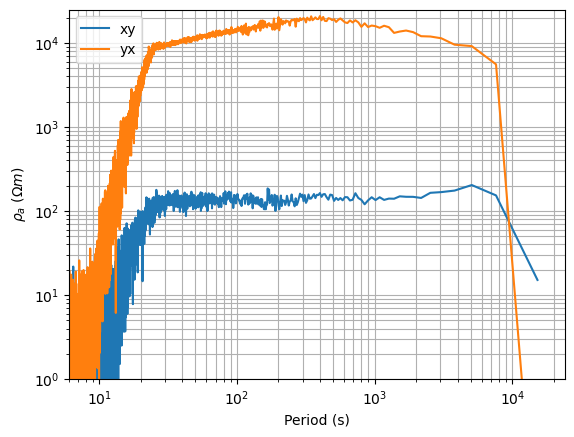

In [17]:
plt.loglog(1/f, rho_a[..., 0, 1], label='xy')
plt.loglog(1/f, rho_a[..., 1, 0], label='yx')
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

## Orienting

In [18]:
cop_orient = cop.orient().split(100).window()

In [19]:
COP_orient = cop_orient.frequency_spectrum().calibrate()

In [20]:
f, Z = mt.calculate_Z(COP_orient)
rho_a = mt.calc_rho_a(f, Z)

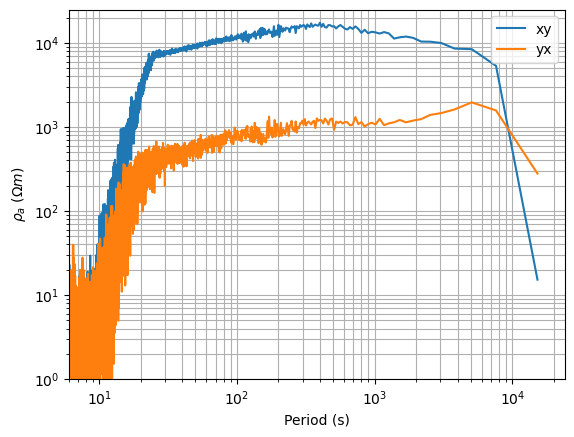

In [21]:
plt.loglog(1/f, rho_a[..., 0, 1], label='xy')
plt.loglog(1/f, rho_a[..., 1, 0], label='yx')
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

## Detrend

In [22]:
cop_detrend = cop.orient().split(100).detrend().window()
COP_detrend = cop_detrend.frequency_spectrum().calibrate()

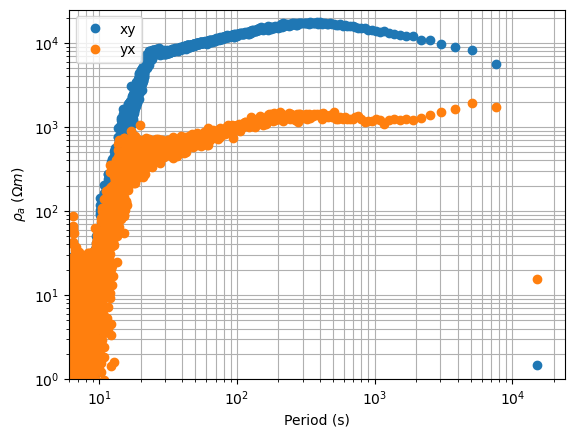

In [23]:
f, Z = mt.calculate_Z(COP_detrend)
rho_a = mt.calc_rho_a(f, Z)

plt.loglog(1/f, rho_a[..., 0, 1], label='xy', marker='o', linestyle="")
plt.loglog(1/f, rho_a[..., 1, 0], label='yx', marker='o', linestyle="")
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

## Frequency Banding

In [48]:
period_bands = np.r_[
    np.logspace(np.log10(7), np.log10(1000), 25),
    np.logspace(np.log10(1000), np.log10(20_000), 5)[1:]
]

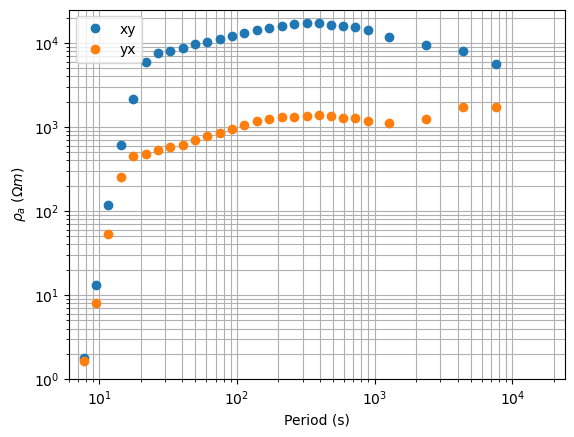

In [49]:
f, Z = mt.calculate_Z(COP_detrend, period_bands=period_bands)
rho_a = mt.calc_rho_a(f, Z)

plt.loglog(1/f, rho_a[..., 0, 1], label='xy', marker='o', linestyle="")
plt.loglog(1/f, rho_a[..., 1, 0], label='yx', marker='o', linestyle="")
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

### Todo:

* Experiment with adjusting the number of splits

* Experiment with the frequency bands

* Remote Referenced!

## Remote Referencing

In [65]:
period_bands_2 = np.r_[
    np.logspace(np.log10(7), np.log10(1000), 25),
    np.logspace(np.log10(1000), np.log10(24000), 7)[1:]
]

In [66]:
cop_overlap, coo_overlap = mt.get_overlapping_series(cop, coo)

In [67]:
cop_rr = cop_overlap.orient().split(10).detrend().window()
COP_rr = cop_rr.frequency_spectrum().calibrate()

coo_rr = coo_overlap.orient().split(10).detrend().window()
COO_rr = coo_rr.frequency_spectrum().calibrate()

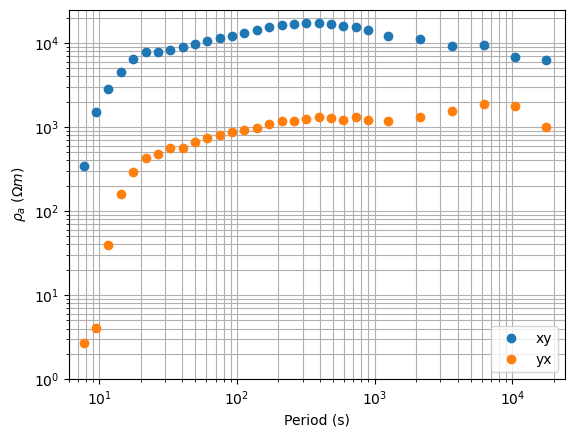

In [68]:
f, Z = mt.calculate_Z(COP_rr, remote=COO_rr, period_bands=period_bands_2)
rho_a = mt.calc_rho_a(f, Z)

plt.loglog(1/f, rho_a[..., 0, 1], label='xy', marker='o', linestyle="")
plt.loglog(1/f, rho_a[..., 1, 0], label='yx', marker='o', linestyle="")
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

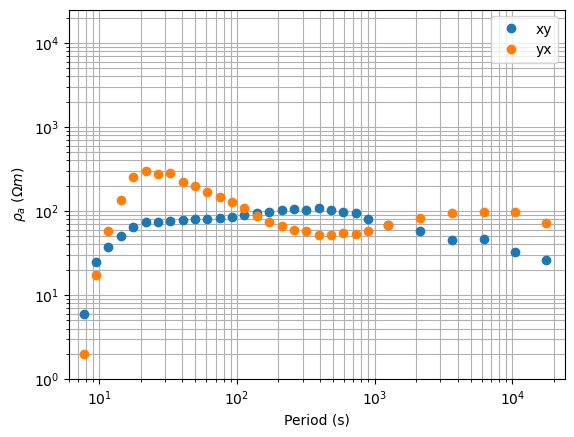

In [69]:
f, Z = mt.calculate_Z(COO_rr, remote=COP_rr, period_bands=period_bands_2)
rho_a = mt.calc_rho_a(f, Z)

plt.loglog(1/f, rho_a[..., 0, 1], label='xy', marker='o', linestyle="")
plt.loglog(1/f, rho_a[..., 1, 0], label='yx', marker='o', linestyle="")
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')